In [1]:
import cv2
import matplotlib.pyplot as plt
from src.preprocessing.preprocess import Preprocessing
import json

In [2]:
# load config:
try:
    with open("config.json", "r", encoding="utf-8") as file:
        loaded_config = json.load(file)
        print("Config successfully loaded!")
except FileNotFoundError:
    print("Error: config.json not found. Falling back to default settings.")
    loaded_config = {}
except json.JSONDecodeError:
    print("Error: Invalid JSON format in config.json. Please check your syntax.")
    loaded_config = {}

Config successfully loaded!


In [3]:
pipeline = Preprocessing(config=loaded_config)
    
image_path = "data\\input\\qr\\qr_withtext.png"


--- Pipeline Results ---
Metadata: {'status': 'success', 'is_blank': False, 'blank_score': 0.01437411426337372, 'comment': 'rf_model (score=0.0144)', 'qr_codes': [CodeDataObject(type='QRCODE', content='sàng tiền minh nguyệt quang', bbox=(48, 48, 145, 145), polygon=[(48, 48), (48, 193), (192, 192), (193, 48)], quality=1)]}


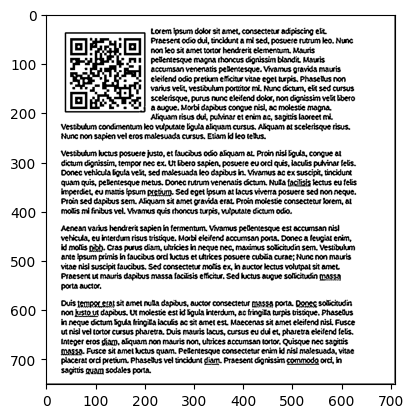

In [4]:
test_image = cv2.imread(image_path)

if test_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    processed_image, meta_data = pipeline._process(test_image)
    
    print("\n--- Pipeline Results ---")
    print(f"Metadata: {meta_data}")
    
plt.imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB))
plt.show()